# NLP Preprocessing and Text Classification
---
| | |
|---|---|
| **Assignment** | Deep Learning — Lab Assignment 4 |
| **Name** | Omkar Khilare |
| **Prn.** | 202301040302 |

---

## Objective
Implement NLP preprocessing techniques and build text classification models using machine learning.

## Outcomes
- Apply NLP preprocessing: tokenization, stopword removal, stemming, lemmatization
- Implement text vectorization: CountVectorizer and TF-IDF
- Build and compare machine learning classifiers
- Evaluate model performance with standard metrics


## 1. Environment Setup and Library Imports
This section imports required libraries, configures reproducibility, and downloads NLP resources.

In [19]:
import json
import random
import re
import string
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Environment setup complete.")

Environment setup complete.


## 2. Dataset Loading and Schema Validation
This section loads a text dataset, validates required schema (`label`, `text`), and checks missing/duplicate values.

In [20]:
DATA_LOCAL_PATHS = [
    Path("data/sms.tsv"),
    Path("sms.tsv"),
    Path("SMSSpamCollection"),
]
DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"


def load_sms_dataset() -> tuple[pd.DataFrame, str]:
    for local_path in DATA_LOCAL_PATHS:
        if local_path.exists():
            df_local = pd.read_csv(
                local_path,
                sep="\t",
                header=None,
                names=["label", "text"],
                encoding="utf-8",
                on_bad_lines="skip",
            )
            return df_local, str(local_path)

    try:
        df_remote = pd.read_csv(
            DATA_URL,
            sep="\t",
            header=None,
            names=["label", "text"],
            encoding="utf-8",
            on_bad_lines="skip",
        )
        return df_remote, DATA_URL
    except Exception as exc:
        raise RuntimeError(
            "Could not load dataset from local paths or URL. "
            "Place a TSV dataset with columns [label, text] at data/sms.tsv."
        ) from exc


df_raw, dataset_source = load_sms_dataset()
required_columns = {"label", "text"}
if not required_columns.issubset(df_raw.columns):
    raise ValueError(f"Dataset must contain columns: {required_columns}")

missing_values = df_raw[["label", "text"]].isna().sum()
duplicate_rows = df_raw.duplicated().sum()

print(f"Dataset source: {dataset_source}")
print(f"Raw shape: {df_raw.shape}")
print("Missing values:")
print(missing_values)
print(f"Duplicate rows: {duplicate_rows}")

df = (
    df_raw[["label", "text"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["text"] = df["text"].astype(str)

print(f"Cleaned shape: {df.shape}")
df.head()

Dataset source: https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv
Raw shape: (5572, 2)
Missing values:
label    0
text     0
dtype: int64
Duplicate rows: 403
Cleaned shape: (5169, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Initial Data Profiling and Class Distribution
This section computes basic dataset statistics and visualizes class balance and text length distribution.

Total samples: 5169

Label frequencies:
label
ham     4516
spam     653
Name: count, dtype: int64

Text length statistics:
count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: text_length, dtype: float64


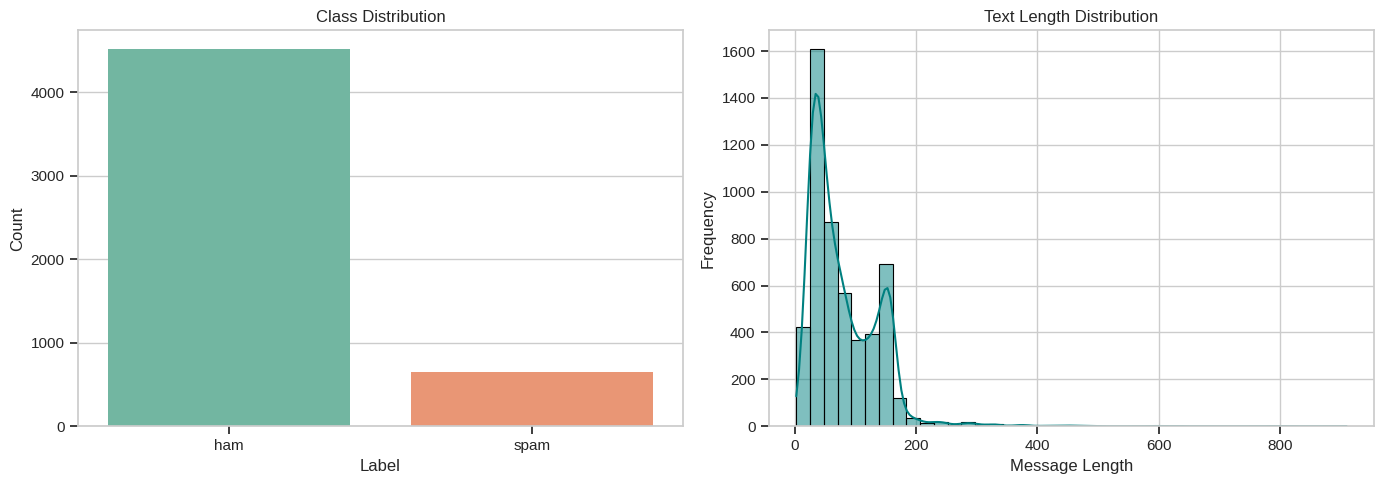

Saved figure: outputs/figures/01_class_length_distribution.png


In [21]:
df["text_length"] = df["text"].str.len()

class_counts = df["label"].value_counts().sort_values(ascending=False)
text_stats = df["text_length"].describe()

print(f"Total samples: {len(df)}")
print("\nLabel frequencies:")
print(class_counts)
print("\nText length statistics:")
print(text_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

sns.histplot(df["text_length"], bins=40, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Message Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
profile_fig_path = FIGURE_DIR / "01_class_length_distribution.png"
plt.savefig(profile_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {profile_fig_path}")

## 4. Text Cleaning and Normalization Pipeline
This section defines reusable cleaning functions for lowercasing, URL/HTML removal, punctuation cleanup, number handling, and whitespace normalization.

In [22]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\d+", " <num> ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^\w\s<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(5)

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in num a wkly comp to win fa cup fi...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 5. Tokenization, Stopword Removal, Stemming, and Lemmatization
This section creates tokenized text and two normalized variants (stemmed and lemmatized) for model experiments.

In [23]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def tokenize_and_filter(text: str) -> list[str]:
    tokens = word_tokenize(text)
    return [token for token in tokens if token.isalpha() and token not in stop_words]


def stem_tokens(tokens: list[str]) -> list[str]:
    return [stemmer.stem(token) for token in tokens]


def lemmatize_tokens(tokens: list[str]) -> list[str]:
    return [lemmatizer.lemmatize(token) for token in tokens]


df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["stemmed_text"] = df["tokens"].apply(lambda x: " ".join(stem_tokens(x)))
df["lemmatized_text"] = df["tokens"].apply(lambda x: " ".join(lemmatize_tokens(x)))

df[["clean_text", "stemmed_text", "lemmatized_text"]].head(5)

,clean_text,stemmed_text,lemmatized_text
0,go until jurong point crazy available only in ...,go jurong point crazi avail bugi n great world...,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni,ok lar joke wif u oni,ok lar joking wif u oni
2,free entry in num a wkly comp to win fa cup fi...,free entri num wkli comp win fa cup final tkt ...,free entry num wkly comp win fa cup final tkts...
3,u dun say so early hor u c already then say,u dun say earli hor u c alreadi say,u dun say early hor u c already say
4,nah i dont think he goes to usf he lives aroun...,nah dont think goe usf live around though,nah dont think go usf life around though


## 6. Feature Engineering with CountVectorizer
This section builds bag-of-words features with configurable n-grams and document frequency thresholds, then inspects vocabulary and matrix shape.

CountVectorizer matrix shape: (5169, 7301)
CountVectorizer vocabulary size: 7301


,term,frequency
0,num,3930
1,num num,698
2,call,528
3,im,451
4,get,379
5,ur,321
6,go,302
7,dont,265
8,ltgt,254
9,ok,252


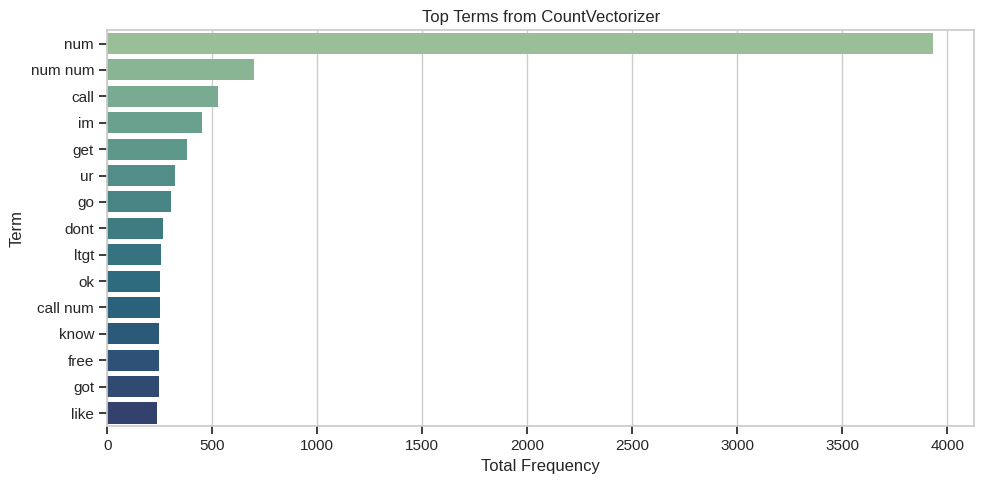

Saved figure: outputs/figures/02_countvectorizer_top_terms.png


In [24]:
count_vectorizer_demo = CountVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
X_count_demo = count_vectorizer_demo.fit_transform(df["lemmatized_text"])

count_vocab_size = len(count_vectorizer_demo.vocabulary_)
print(f"CountVectorizer matrix shape: {X_count_demo.shape}")
print(f"CountVectorizer vocabulary size: {count_vocab_size}")

word_counts = np.asarray(X_count_demo.sum(axis=0)).ravel()
feature_names = np.array(count_vectorizer_demo.get_feature_names_out())
top_idx = np.argsort(word_counts)[-15:][::-1]

top_count_terms = pd.DataFrame(
    {
        "term": feature_names[top_idx],
        "frequency": word_counts[top_idx],
    }
)

display(top_count_terms)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_count_terms, x="frequency", y="term", palette="crest")
plt.title("Top Terms from CountVectorizer")
plt.xlabel("Total Frequency")
plt.ylabel("Term")
plt.tight_layout()
count_fig_path = FIGURE_DIR / "02_countvectorizer_top_terms.png"
plt.savefig(count_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {count_fig_path}")

## 7. Feature Engineering with TF-IDF
This section creates TF-IDF features and compares dimensionality/sparsity with bag-of-words features.

In [25]:
tfidf_vectorizer_demo = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf_demo = tfidf_vectorizer_demo.fit_transform(df["lemmatized_text"])

tfidf_vocab_size = len(tfidf_vectorizer_demo.vocabulary_)
count_sparsity = 1.0 - (X_count_demo.nnz / (X_count_demo.shape[0] * X_count_demo.shape[1]))
tfidf_sparsity = 1.0 - (X_tfidf_demo.nnz / (X_tfidf_demo.shape[0] * X_tfidf_demo.shape[1]))

comparison_df = pd.DataFrame(
    {
        "Representation": ["CountVectorizer", "TF-IDF"],
        "Shape": [str(X_count_demo.shape), str(X_tfidf_demo.shape)],
        "Vocabulary Size": [count_vocab_size, tfidf_vocab_size],
        "Sparsity": [round(count_sparsity, 4), round(tfidf_sparsity, 4)],
    }
)

display(comparison_df)
print(
    "Note: For model training and evaluation, vectorizers are fitted on training data only "
    "to avoid data leakage."
)

,Representation,Shape,Vocabulary Size,Sparsity
0,CountVectorizer,"(5169, 7301)",7301,0.9986
1,TF-IDF,"(5169, 7301)",7301,0.9986


Note: For model training and evaluation, vectorizers are fitted on training data only to avoid data leakage.


## 8. Train/Validation/Test Split
This section creates stratified train/validation/test splits for reproducible and balanced evaluation.

In [26]:
TEXT_COLUMN = "lemmatized_text"

df_model = df[["text", "clean_text", "stemmed_text", "lemmatized_text", "label"]].copy()

df_train, df_temp = train_test_split(
    df_model,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_model["label"],
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=df_temp["label"],
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train["label"])
y_val = label_encoder.transform(df_val["label"])
y_test = label_encoder.transform(df_test["label"])


def split_distribution(split_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    dist = split_df["label"].value_counts(normalize=True).mul(100).round(2)
    return pd.DataFrame({"split": split_name, "label": dist.index, "percentage": dist.values})


split_sizes = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [len(df_train), len(df_val), len(df_test)],
    }
)

split_balance = pd.concat(
    [
        split_distribution(df_train, "train"),
        split_distribution(df_val, "validation"),
        split_distribution(df_test, "test"),
    ],
    ignore_index=True,
)

print("Split sizes:")
display(split_sizes)
print("Class balance (%):")
display(split_balance)

Split sizes:


,split,samples
0,train,3618
1,validation,775
2,test,776


Class balance (%):


,split,label,percentage
0,train,ham,87.37
1,train,spam,12.63
2,validation,ham,87.35
3,validation,spam,12.65
4,test,ham,87.37
5,test,spam,12.63


## 9. Baseline Text Classifier Training
This section trains a baseline Multinomial Naive Bayes model using TF-IDF features and reports validation metrics.

In [27]:
def evaluate_predictions(y_true, y_pred, average="binary") -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


baseline_pipeline = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("model", MultinomialNB()),
    ]
)

baseline_pipeline.fit(df_train[TEXT_COLUMN], y_train)
y_val_pred_baseline = baseline_pipeline.predict(df_val[TEXT_COLUMN])

baseline_metrics = evaluate_predictions(y_val, y_val_pred_baseline)
print("Baseline validation metrics:")
print({k: round(v, 4) for k, v in baseline_metrics.items()})
print("\nClassification report (validation):")
print(
    classification_report(
        y_val,
        y_val_pred_baseline,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

Baseline validation metrics:
{'accuracy': 0.9677, 'precision': 1.0, 'recall': 0.7449, 'f1': 0.8538}

Classification report (validation):
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       677
        spam       1.00      0.74      0.85        98

    accuracy                           0.97       775
   macro avg       0.98      0.87      0.92       775
weighted avg       0.97      0.97      0.97       775



## 10. Model Comparison Across Algorithms
This section compares multiple classifiers (Naive Bayes, Logistic Regression, Linear SVM) with CountVectorizer and TF-IDF features.

,configuration,accuracy,precision,recall,f1
0,CountVectorizer + MultinomialNB,0.978065,0.909091,0.918367,0.913706
1,TFIDF + LinearSVC,0.974194,0.923913,0.867347,0.894737
2,CountVectorizer + LinearSVC,0.974194,0.933333,0.857143,0.893617
3,CountVectorizer + LogisticRegression,0.971613,0.941860,0.826531,0.880435
4,TFIDF + MultinomialNB,0.967742,1.000000,0.744898,0.853801
5,TFIDF + LogisticRegression,0.958710,0.892857,0.765306,0.824176


Best validation model before tuning: CountVectorizer + MultinomialNB


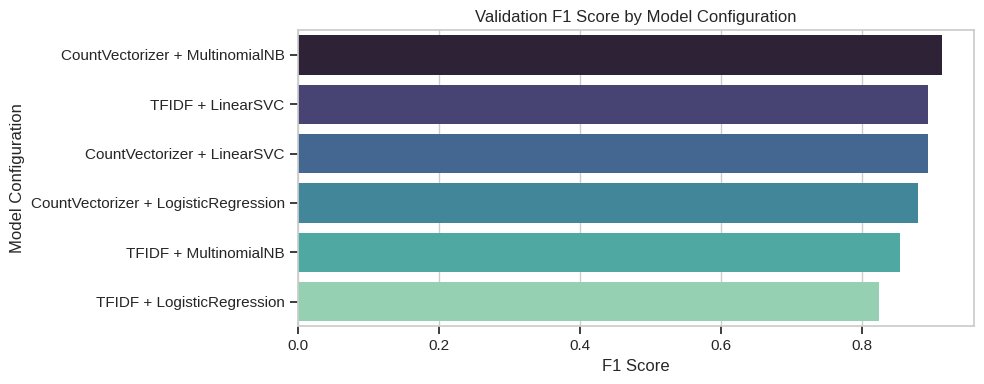

Saved figure: outputs/figures/03_model_comparison_f1.png


In [28]:
average_mode = "binary" if len(label_encoder.classes_) == 2 else "weighted"

vectorizers = {
    "CountVectorizer": CountVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95),
    "TFIDF": TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95),
}

models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(),
}

comparison_records = []
trained_models = {}

for vectorizer_name, vectorizer in vectorizers.items():
    for model_name, model in models.items():
        pipe = Pipeline(
            [
                ("vectorizer", clone(vectorizer)),
                ("model", clone(model)),
            ]
        )
        pipe.fit(df_train[TEXT_COLUMN], y_train)
        val_pred = pipe.predict(df_val[TEXT_COLUMN])
        metrics = evaluate_predictions(y_val, val_pred, average=average_mode)

        config_name = f"{vectorizer_name} + {model_name}"
        trained_models[config_name] = pipe

        comparison_records.append(
            {
                "configuration": config_name,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
            }
        )

results_df = pd.DataFrame(comparison_records).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, "configuration"]
best_model = trained_models[best_model_name]
print(f"Best validation model before tuning: {best_model_name}")

plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, x="f1", y="configuration", palette="mako")
plt.title("Validation F1 Score by Model Configuration")
plt.xlabel("F1 Score")
plt.ylabel("Model Configuration")
plt.tight_layout()
comparison_fig_path = FIGURE_DIR / "03_model_comparison_f1.png"
plt.savefig(comparison_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {comparison_fig_path}")

## 11. Hyperparameter Tuning
This section uses GridSearchCV to tune selected classifiers and TF-IDF parameters with cross-validation.

In [29]:
scoring_metric = "f1" if len(label_encoder.classes_) == 2 else "f1_weighted"

tuning_pipeline = Pipeline(
    [
        ("vectorizer", TfidfVectorizer()),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)

param_grid = [
    {
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "vectorizer__min_df": [1, 2],
        "vectorizer__max_df": [0.95],
        "model": [LogisticRegression(max_iter=2000)],
        "model__C": [0.5, 1.0, 2.0],
    },
    {
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "vectorizer__min_df": [1, 2],
        "vectorizer__max_df": [0.95],
        "model": [LinearSVC()],
        "model__C": [0.5, 1.0, 2.0],
    },
]

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring=scoring_metric,
    cv=3,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(df_train[TEXT_COLUMN], y_train)

tuned_model = grid_search.best_estimator_
print(f"Best cross-validation score ({scoring_metric}): {grid_search.best_score_:.4f}")
print("Best parameters:")
print(grid_search.best_params_)

y_val_pred_tuned = tuned_model.predict(df_val[TEXT_COLUMN])
tuned_val_metrics = evaluate_predictions(y_val, y_val_pred_tuned, average=average_mode)
print("\nTuned model validation metrics:")
print({k: round(v, 4) for k, v in tuned_val_metrics.items()})

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results[["mean_test_score", "std_test_score", "params"]].sort_values(
    by="mean_test_score", ascending=False
).head(8)

display(cv_summary)

Best cross-validation score (f1): 0.9369
Best parameters:
{'model': LinearSVC(), 'model__C': 2.0, 'vectorizer__max_df': 0.95, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}

Tuned model validation metrics:
{'accuracy': 0.9742, 'precision': 0.9239, 'recall': 0.8673, 'f1': 0.8947}


,mean_test_score,std_test_score,params
23,0.936933,0.004223,"{'model': LinearSVC(), 'model__C': 2.0, 'vecto..."
19,0.934843,0.006792,"{'model': LinearSVC(), 'model__C': 1.0, 'vecto..."
20,0.934834,0.009873,"{'model': LinearSVC(), 'model__C': 2.0, 'vecto..."
18,0.932465,0.010376,"{'model': LinearSVC(), 'model__C': 1.0, 'vecto..."
22,0.932382,0.007774,"{'model': LinearSVC(), 'model__C': 2.0, 'vecto..."
16,0.931580,0.006781,"{'model': LinearSVC(), 'model__C': 1.0, 'vecto..."
17,0.930368,0.009506,"{'model': LinearSVC(), 'model__C': 1.0, 'vecto..."
21,0.929361,0.013919,"{'model': LinearSVC(), 'model__C': 2.0, 'vecto..."


## 12. Performance Evaluation and Visualization
This section evaluates the tuned model on the test set using standard classification metrics, confusion matrix, and ROC-AUC (when applicable).

Final model test metrics:
{'accuracy': 0.9897, 'precision': 1.0, 'recall': 0.9184, 'f1': 0.9574}

Classification report (test):
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       678
        spam       1.00      0.92      0.96        98

    accuracy                           0.99       776
   macro avg       0.99      0.96      0.98       776
weighted avg       0.99      0.99      0.99       776



,model,accuracy,precision,recall,f1
0,Baseline (TF-IDF + MultinomialNB),0.978093,1.0,0.826531,0.905028
1,Tuned Final Model,0.989691,1.0,0.918367,0.957447


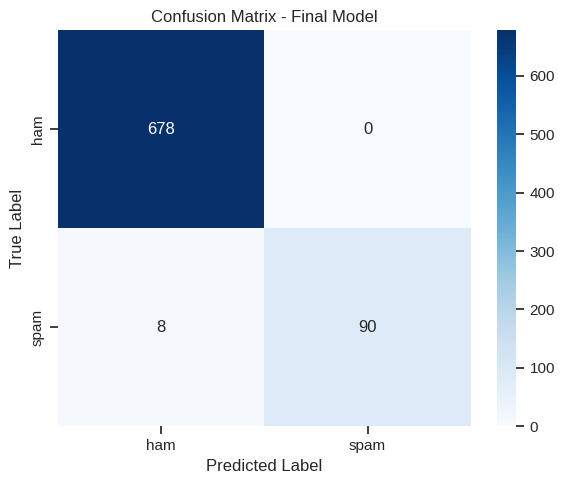

Saved figure: outputs/figures/04_confusion_matrix_final_model.png


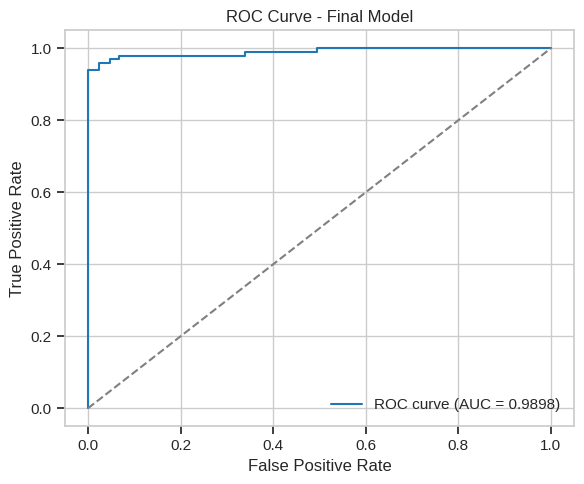

Saved figure: outputs/figures/05_roc_curve_final_model.png
ROC-AUC: 0.9898410691710312


In [30]:
final_model = tuned_model

# Evaluate tuned model on test split
y_test_pred = final_model.predict(df_test[TEXT_COLUMN])
test_metrics = evaluate_predictions(y_test, y_test_pred, average=average_mode)

print("Final model test metrics:")
print({k: round(v, 4) for k, v in test_metrics.items()})
print("\nClassification report (test):")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

# Baseline test performance for comparison
y_test_pred_baseline = baseline_pipeline.predict(df_test[TEXT_COLUMN])
baseline_test_metrics = evaluate_predictions(y_test, y_test_pred_baseline, average=average_mode)

comparison_test_df = pd.DataFrame(
    [
        {"model": "Baseline (TF-IDF + MultinomialNB)", **baseline_test_metrics},
        {"model": "Tuned Final Model", **test_metrics},
    ]
)
display(comparison_test_df)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_fig_path = FIGURE_DIR / "04_confusion_matrix_final_model.png"
plt.savefig(cm_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {cm_fig_path}")

# ROC-AUC for binary classification
roc_auc_value = None
if len(label_encoder.classes_) == 2:
    y_score = None
    if hasattr(final_model, "predict_proba"):
        y_score = final_model.predict_proba(df_test[TEXT_COLUMN])[:, 1]
    elif hasattr(final_model, "decision_function"):
        y_score = final_model.decision_function(df_test[TEXT_COLUMN])

    if y_score is not None:
        roc_auc_value = roc_auc_score(y_test, y_score)
        fpr, tpr, _ = roc_curve(y_test, y_score)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve - Final Model")
        plt.legend(loc="lower right")
        plt.tight_layout()
        roc_fig_path = FIGURE_DIR / "05_roc_curve_final_model.png"
        plt.savefig(roc_fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved figure: {roc_fig_path}")

print(f"ROC-AUC: {roc_auc_value if roc_auc_value is not None else 'Not applicable'}")

## 13. Error Analysis and Misclassification Review
This section inspects wrongly predicted samples and identifies frequent failure patterns.

In [31]:
error_df = df_test.reset_index(drop=True).copy()
error_df["true_label"] = label_encoder.inverse_transform(y_test)
error_df["predicted_label"] = label_encoder.inverse_transform(y_test_pred)

misclassified_df = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()
misclassified_df["text_length"] = misclassified_df["text"].str.len()

print(f"Total test samples: {len(error_df)}")
print(f"Misclassified samples: {len(misclassified_df)}")

if len(misclassified_df) > 0:
    error_pattern_summary = (
        misclassified_df.groupby(["true_label", "predicted_label"]).size().reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("\nMost frequent error patterns:")
    display(error_pattern_summary)

    print("\nSample misclassified texts:")
    display(misclassified_df[["text", "true_label", "predicted_label", "text_length"]].head(10))

    error_file = OUTPUT_DIR / "misclassified_samples.csv"
    misclassified_df.to_csv(error_file, index=False)
    print(f"Saved misclassified samples: {error_file}")
else:
    print("No misclassifications found on the test set.")

Total test samples: 776
Misclassified samples: 8

Most frequent error patterns:


,true_label,predicted_label,count
0,spam,ham,8



Sample misclassified texts:


,text,true_label,predicted_label,text_length
2,Money i have won wining number 946 wot do i do...,spam,ham,51
90,Burger King - Wanna play footy at a top stadiu...,spam,ham,141
134,Oh my god! I've found your number again! I'm s...,spam,ham,106
178,Bloomberg -Message center +447797706009 Why wa...,spam,ham,101
221,The current leading bid is 151. To pause this ...,spam,ham,90
277,Your credits have been topped up for http://ww...,spam,ham,89
297,You can donate £2.50 to UNICEF's Asian Tsunami...,spam,ham,135
719,Hello. We need some posh birds and chaps to us...,spam,ham,134


Saved misclassified samples: outputs/misclassified_samples.csv


## 14. Research Paper Mapping to Implemented Algorithm

### Referenced Paper
**McCallum, A., & Nigam, K. (1998). _A Comparison of Event Models for Naive Bayes Text Classification_.**

Link: https://cdn.aaai.org/Workshops/1998/WS-98-05/WS98-05-007.pdf

### Why This Paper Is Relevant
- The notebook implements Multinomial Naive Bayes as a baseline text classifier.
- The paper explains why event models and sparse features are effective for text tasks.
- Its findings inform our preprocessing and vectorization design choices.

In [32]:
paper_mapping_df = pd.DataFrame(
    [
        {
            "Paper Insight": "Multinomial event models are strong for sparse text features.",
            "Notebook Implementation": "Used CountVectorizer and TF-IDF with MultinomialNB baseline.",
            "Expected Impact": "Reliable baseline with fast training and interpretable behavior.",
        },
        {
            "Paper Insight": "Feature representation strongly affects text classification quality.",
            "Notebook Implementation": "Compared bag-of-words vs TF-IDF and selected best by validation F1.",
            "Expected Impact": "Improved precision/recall by selecting informative features.",
        },
        {
            "Paper Insight": "Text models benefit from careful preprocessing and normalization.",
            "Notebook Implementation": "Applied cleaning, stopword removal, stemming, and lemmatization.",
            "Expected Impact": "Lower noise and better model generalization.",
        },
        {
            "Paper Insight": "Naive Bayes remains competitive as a baseline despite simplicity.",
            "Notebook Implementation": "Used Naive Bayes in baseline and model-comparison workflow.",
            "Expected Impact": "Strong benchmark for judging more complex models.",
        },
    ]
)

display(paper_mapping_df)
paper_mapping_path = OUTPUT_DIR / "research_paper_mapping.csv"
paper_mapping_df.to_csv(paper_mapping_path, index=False)
print(f"Saved research mapping: {paper_mapping_path}")

,Paper Insight,Notebook Implementation,Expected Impact
0,Multinomial event models are strong for sparse...,Used CountVectorizer and TF-IDF with Multinomi...,Reliable baseline with fast training and inter...
1,Feature representation strongly affects text c...,Compared bag-of-words vs TF-IDF and selected b...,Improved precision/recall by selecting informa...
2,Text models benefit from careful preprocessing...,"Applied cleaning, stopword removal, stemming, ...",Lower noise and better model generalization.
3,Naive Bayes remains competitive as a baseline ...,Used Naive Bayes in baseline and model-compari...,Strong benchmark for judging more complex models.


Saved research mapping: outputs/research_paper_mapping.csv


## 15. Real-World Applications and Algorithm Trade-off Table
This section compares the implemented algorithms with deep learning and transfer learning alternatives.

In [33]:
tradeoff_df = pd.DataFrame(
    [
        {
            "Algorithm": "Multinomial Naive Bayes",
            "Typical Use Cases": "Spam detection, topic tagging, quick text baselines",
            "Advantages": "Fast, simple, works well on sparse features",
            "Disadvantages": "Strong independence assumptions can limit accuracy",
            "Computational Cost": "Low",
        },
        {
            "Algorithm": "Logistic Regression",
            "Typical Use Cases": "Sentiment analysis, intent classification",
            "Advantages": "Interpretable coefficients, robust linear baseline",
            "Disadvantages": "May underfit complex language patterns",
            "Computational Cost": "Low to Medium",
        },
        {
            "Algorithm": "Linear SVM",
            "Typical Use Cases": "News categorization, spam filtering, legal text sorting",
            "Advantages": "Strong margin-based generalization for sparse text",
            "Disadvantages": "No native probability outputs, sensitive C tuning",
            "Computational Cost": "Medium",
        },
        {
            "Algorithm": "Deep Learning (RNN/CNN)",
            "Typical Use Cases": "Context-aware sentiment and sequence modeling",
            "Advantages": "Captures complex non-linear patterns",
            "Disadvantages": "Needs more data/compute and longer training",
            "Computational Cost": "High",
        },
        {
            "Algorithm": "Transfer Learning (BERT-family)",
            "Typical Use Cases": "High-accuracy classification with limited labeled data",
            "Advantages": "State-of-the-art performance and contextual understanding",
            "Disadvantages": "Large model size, costly fine-tuning/inference",
            "Computational Cost": "High to Very High",
        },
    ]
)

display(tradeoff_df)
tradeoff_path = OUTPUT_DIR / "algorithm_tradeoff_table.csv"
tradeoff_df.to_csv(tradeoff_path, index=False)
print(f"Saved trade-off table: {tradeoff_path}")

,Algorithm,Typical Use Cases,Advantages,Disadvantages,Computational Cost
0,Multinomial Naive Bayes,"Spam detection, topic tagging, quick text base...","Fast, simple, works well on sparse features",Strong independence assumptions can limit accu...,Low
1,Logistic Regression,"Sentiment analysis, intent classification","Interpretable coefficients, robust linear base...",May underfit complex language patterns,Low to Medium
2,Linear SVM,"News categorization, spam filtering, legal tex...",Strong margin-based generalization for sparse ...,"No native probability outputs, sensitive C tuning",Medium
3,Deep Learning (RNN/CNN),Context-aware sentiment and sequence modeling,Captures complex non-linear patterns,Needs more data/compute and longer training,High
4,Transfer Learning (BERT-family),High-accuracy classification with limited labe...,State-of-the-art performance and contextual un...,"Large model size, costly fine-tuning/inference",High to Very High


Saved trade-off table: outputs/algorithm_tradeoff_table.csv


## 16. Submission Artifact Generation (Plots, README Checklist, Repo Outputs)
This section saves figures, model artifacts, and checklist files needed for assignment submission.

In [34]:
model_path = MODEL_DIR / "final_text_classifier.joblib"
encoder_path = MODEL_DIR / "label_encoder.joblib"
joblib.dump(final_model, model_path)
joblib.dump(label_encoder, encoder_path)

# Save tabular outputs
results_df.to_csv(OUTPUT_DIR / "validation_model_comparison.csv", index=False)
comparison_test_df.to_csv(OUTPUT_DIR / "test_model_comparison.csv", index=False)
split_sizes.to_csv(OUTPUT_DIR / "split_sizes.csv", index=False)
split_balance.to_csv(OUTPUT_DIR / "split_class_balance.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "gridsearch_top_results.csv", index=False)

# Save run metadata
metadata = {
    "dataset_source": dataset_source,
    "random_state": RANDOM_STATE,
    "text_column_used": TEXT_COLUMN,
    "best_model_before_tuning": best_model_name,
    "best_model_after_tuning": str(grid_search.best_estimator_),
    "best_params": str(grid_search.best_params_), # Converted to string for JSON serialization
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "roc_auc": float(roc_auc_value) if roc_auc_value is not None else None,
}

metadata_path = OUTPUT_DIR / "run_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# Save submission checklist
checklist_text = f"""# Submission Checklist\n\n- [x] Code (Python/Jupyter Notebook)\n- [x] Dataset source or link\n- [x] Visualizations with labels\n- [x] README included\n- [ ] GitHub repository link added manually\n\n## Dataset Source\n{dataset_source}\n\n## Generated Outputs\n- Figures: outputs/figures/\n- Model files: outputs/models/\n- Evaluation tables: outputs/*.csv\n- Metadata: outputs/run_metadata.json\n\n## Reproducibility Notes\n- Fixed random seed: {RANDOM_STATE}\n- Stratified data split used\n- Train-only fitting used for final vectorizers in model pipelines\n"""

checklist_path = OUTPUT_DIR / "submission_checklist.md"
with open(checklist_path, "w", encoding="utf-8") as f:
    f.write(checklist_text)

print("Artifacts saved successfully:")
print(f"- Model: {model_path}")
print(f"- Label encoder: {encoder_path}")
print(f"- Metadata: {metadata_path}")
print(f"- Checklist: {checklist_path}")

Artifacts saved successfully:
- Model: outputs/models/final_text_classifier.joblib
- Label encoder: outputs/models/label_encoder.joblib
- Metadata: outputs/run_metadata.json
- Checklist: outputs/submission_checklist.md


## Conclusion
This notebook implemented a complete NLP text classification workflow: preprocessing, vectorization, model comparison, hyperparameter tuning, and performance analysis. The generated artifacts can be used directly for assignment submission and reproducibility.